# Tarea 2
### Francisco Javier Villarroel Herrera

In [1]:
#Importamos todas las librerias a trabajar

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy
import linearmodels.panel as lmp
import pytwoway as tw
import bipartitepandas as bpd
from linearmodels.iv import IV2SLS
from scipy.stats import nbinom
from statsmodels.iolib.summary2 import summary_col

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

c:\Users\Francisco Villarroel\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Diccionario de Variables**

- folio_n20: identificación individuo 
- year:	año 20xx
- time:	ronda de la encuesta (1-7)
- age:	edad
- hombre:	1 si hombre, 0 mujer
- edu:	educación medida en años completados 
- region:	región (1-16) 
- status:	1 casado 2 convive 3 divorciado 4 viudo 5 soltero
- kids:	1 si tiene hijos, 0 si no
- children:	# de hijos menores de 18 años, 18 incluido
- situation: 1 otro, 2 cesante, 3 trabajando, 4 inactivo
- lmp:	1 trabajador a tiempo parcial, 2 trabajador a tiempo completo, 0 no trabaja
- exp:	años de experiencia laboral
- size:	tamaño de la firma 
- occupation:	código ocupación 
- wage:	salario mensual en pesos del año encuesta
- hours:	horas semanales trabajadas
- informal: 1 si no hay contrato de trabajo, 0 si lo hay
- selfemp: 1 si trabajador autónomo, 0 si no
- publicemp:	1 si trabaja en el sector público, 0 si no
- sistema:	1 si en sistema AFP, 0 si no
- cotizando:	1 si cotizante, 0 si no
- assets:	patrimonio acumulado en sistema de pensiones, pesos de cada año
- exp_sist:	años de experiencia en sistema de pensiones
- expectancy:	expectativa de vida autorreportada
- illness:	1 si tiene al menos una enfermedad, 0 eoc 
- cronica:	Si tiene enfermedad crónica 1, 0 eoc 
- nocronica:	Si tiene enfermedad no crónica 1, 0 eoc 
- mental:	Si tiene enfermedad mental 1, 0 eoc

**Análisis preliminares de la data**

1. Las últimas 3 columna tienen el mismo número de NaN: 16309 (17%).
2. Las variables asociadas a la empresa y puesto, size, occupation, wage, hours, informal, selfemp y publicemp presentan muchos datos faltantes.
3. Supuesto las rondas están en intervalos idénticos

## 1. Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.

In [2]:
#Cargamos el dataframe
df = pd.read_csv('../../data/panel_eps.csv')
df

,folio_n20,year,time,edad,hombre,edu,region,status,kids,children,...,fondob,fondoc,fondod,fondoe,exp_sist,expectancy,illness,cronica,nocronica,mental
0,124560204870,4,2,49,0.0,7.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,58.0,1.0,0.0,1.0,0.0
1,124560204870,6,3,51,0.0,4.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,55.0,0.0,0.0,0.0,0.0
2,124560204870,9,4,54,0.0,5.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,70.0,1.0,0.0,0.0,1.0
3,124560204870,12,5,57,0.0,4.0,NaN,5.0,0,0.0,...,NaN,NaN,NaN,NaN,0,70.0,1.0,0.0,0.0,0.0
4,124560205935,2,1,1982,0.0,15.0,13.0,3.0,1,4.0,...,NaN,NaN,NaN,NaN,19,75.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96841,128133653188,12,5,1992,0.0,16.0,NaN,3.0,0,0.0,...,NaN,NaN,NaN,NaN,7,80.0,0.0,0.0,0.0,0.0
96842,128133692735,12,5,1992,0.0,12.0,NaN,2.0,0,0.0,...,NaN,NaN,NaN,NaN,7,80.0,1.0,0.0,0.0,0.0
96843,128133702320,12,5,1992,0.0,15.0,NaN,5.0,0,0.0,...,NaN,NaN,NaN,NaN,7,75.0,0.0,0.0,0.0,0.0
96844,128133728022,12,5,1992,0.0,8.0,NaN,2.0,0,0.0,...,NaN,NaN,NaN,NaN,6,70.0,1.0,0.0,0.0,0.0


In [3]:
df.describe()

,folio_n20,year,time,edad,hombre,edu,region,status,kids,children,...,fondob,fondoc,fondod,fondoe,exp_sist,expectancy,illness,cronica,nocronica,mental
count,9.684600e+04,96846.000000,96846.000000,96846.000000,96796.000000,92920.000000,80848.000000,96736.00000,96846.000000,78017.000000,...,0.0,0.0,0.0,0.0,96846.000000,70281.000000,80408.000000,80537.000000,80537.000000,80537.000000
mean,1.253178e+11,7.991213,3.493898,1673.399903,0.494979,7.905585,9.148959,2.62378,0.357082,0.741633,...,NaN,NaN,NaN,NaN,13.473432,131.131273,0.361096,0.213144,0.073084,0.074289
std,1.296642e+09,4.566324,1.727313,711.910128,0.499977,5.106440,3.678007,1.73293,0.479142,1.013718,...,NaN,NaN,NaN,NaN,10.354177,216.851544,0.480321,0.409531,0.260277,0.262242
min,1.245602e+11,2.000000,1.000000,20.000000,0.000000,0.000000,1.000000,1.00000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000
25%,1.246212e+11,4.000000,2.000000,1982.000000,0.000000,3.000000,6.000000,1.00000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,3.000000,70.000000,0.000000,0.000000,0.000000,0.000000
50%,1.247076e+11,6.000000,3.000000,1986.000000,0.000000,7.000000,9.000000,2.00000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,14.000000,80.000000,0.000000,0.000000,0.000000,0.000000
75%,1.248369e+11,12.000000,5.000000,1992.000000,1.000000,12.000000,13.000000,5.00000,1.000000,1.000000,...,NaN,NaN,NaN,NaN,22.000000,85.000000,1.000000,0.000000,0.000000,0.000000
max,1.281337e+11,15.000000,6.000000,1996.000000,1.000000,19.000000,15.000000,5.00000,1.000000,8.000000,...,NaN,NaN,NaN,NaN,35.000000,999.000000,1.000000,1.000000,1.000000,1.000000


In [4]:
df.dtypes

folio_n20       int64
year            int64
time            int64
edad            int64
hombre        float64
edu           float64
region        float64
status        float64
kids            int64
children      float64
situation       int64
lmp             int64
exp           float64
size          float64
occupation    float64
wage          float64
hours         float64
informal      float64
selfemp       float64
publicemp     float64
sistema       float64
cotizando     float64
assets        float64
fondoa        float64
fondob        float64
fondoc        float64
fondod        float64
fondoe        float64
exp_sist        int64
expectancy    float64
illness       float64
cronica       float64
nocronica     float64
mental        float64
dtype: object

Procedemos a descartas las columnas con más de un 30% de NaN.

In [5]:
# Porcentajes de NaN en columnas críticas.

# region        17%
# children      19%
# exp           12%
# size          70%
# occupation    49%
# wage          44%
# hours         44%
# informal      57%
# selfemp       43%
# publicemp     43%
# sistema       21%
# assets        17%
# fondoa        100%
# fondob        100%
# fondoc        100%
# fondod        100%
# fondoe        100%
# expectancy    27%
# illness       17%
# cronica       17%
# nocronica     17%
# mental        17%

# Se dejaran de lado las que presenten más de un 30%.

df = df.drop(['size', 'occupation', 'wage', 'hours', 'informal', 'selfemp','publicemp','fondoa','fondob','fondoc','fondod','fondoe'], axis=1)

Ahora realizaremos un análisis de los valores nulos presentes en cada ronda, para determinar una estrategia a seguir para seguir limpiando la base de datos.

In [6]:
df1 = df[df['time'] == 1]
df1

# Porcentajes de NaN en Ronda 1.

# illness       100%
# cronica       100%
# nocronica     100%
# mental        100%

,folio_n20,year,time,edad,hombre,edu,region,status,kids,children,...,exp,sistema,cotizando,assets,exp_sist,expectancy,illness,cronica,nocronica,mental
4,124560205935,2,1,1982,0.0,15.0,13.0,3.0,1,4.0,...,6.0,1.0,0.0,989038.060,19,75.0,NaN,NaN,NaN,NaN
6,124560210408,2,1,1982,0.0,4.0,13.0,1.0,1,1.0,...,22.0,1.0,1.0,89575.539,4,70.0,NaN,NaN,NaN,NaN
12,124560216585,2,1,1982,0.0,7.0,5.0,3.0,1,1.0,...,8.0,0.0,0.0,56305.316,1,65.0,NaN,NaN,NaN,NaN
22,124560233980,2,1,1982,0.0,14.0,5.0,2.0,0,0.0,...,18.0,1.0,1.0,430287.530,16,75.0,NaN,NaN,NaN,NaN
27,124560240157,2,1,48,1.0,3.0,6.0,5.0,0,0.0,...,19.0,0.0,0.0,0.000,0,70.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95545,128122210402,2,1,1982,1.0,14.0,5.0,5.0,0,NaN,...,2.0,1.0,1.0,485808.280,12,70.0,NaN,NaN,NaN,NaN
95621,128123108481,2,1,1982,0.0,3.0,5.0,5.0,1,1.0,...,13.0,1.0,1.0,37072.797,12,70.0,NaN,NaN,NaN,NaN
95871,128123880677,2,1,1982,1.0,17.0,5.0,5.0,0,NaN,...,0.0,1.0,0.0,79474.453,6,50.0,NaN,NaN,NaN,NaN
95877,128123885789,2,1,1982,1.0,11.0,12.0,1.0,1,1.0,...,5.0,1.0,1.0,0.000,0,80.0,NaN,NaN,NaN,NaN


In [7]:
df2 = df[df['time'] == 2]
df2


# Porcentajes de NaN en Ronda 2.

# children 14%
# sistema 24%

,folio_n20,year,time,edad,hombre,edu,region,status,kids,children,...,exp,sistema,cotizando,assets,exp_sist,expectancy,illness,cronica,nocronica,mental
0,124560204870,4,2,49,0.0,7.0,5.0,3.0,1,1.0,...,NaN,NaN,0.0,0.00,0,58.0,1.0,0.0,1.0,0.0
5,124560205935,4,2,1984,0.0,15.0,13.0,3.0,1,3.0,...,6.0,1.0,0.0,0.00,21,70.0,1.0,1.0,1.0,0.0
7,124560210408,4,2,1984,0.0,4.0,13.0,1.0,0,0.0,...,23.0,1.0,1.0,0.00,6,70.0,0.0,0.0,0.0,0.0
13,124560216585,4,2,1984,0.0,7.0,5.0,1.0,1,1.0,...,10.0,1.0,1.0,316794.38,3,80.0,1.0,0.0,1.0,0.0
17,124560229507,4,2,50,0.0,4.0,13.0,3.0,1,1.0,...,NaN,NaN,0.0,0.00,0,NaN,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96007,128124395498,4,2,63,0.0,3.0,13.0,2.0,0,0.0,...,0.0,NaN,0.0,0.00,0,80.0,1.0,1.0,0.0,0.0
96011,128124406148,4,2,1985,0.0,7.0,13.0,1.0,1,3.0,...,2.0,NaN,0.0,0.00,13,NaN,1.0,1.0,0.0,0.0
96014,128124411118,4,2,58,0.0,7.0,13.0,1.0,0,0.0,...,0.0,NaN,0.0,0.00,0,NaN,0.0,0.0,0.0,0.0
96017,128124417295,4,2,50,1.0,7.0,8.0,1.0,0,0.0,...,19.0,NaN,0.0,0.00,0,NaN,0.0,0.0,0.0,0.0


In [8]:
df3 = df[df['time'] == 3]
df3

# Porcentajes de NaN en Ronda 3.

# sistema 24%
# expectancy 24%

,folio_n20,year,time,edad,hombre,edu,region,status,kids,children,...,exp,sistema,cotizando,assets,exp_sist,expectancy,illness,cronica,nocronica,mental
1,124560204870,6,3,51,0.0,4.0,5.0,3.0,1,1.0,...,NaN,0.0,0.0,0.0,0,55.0,0.0,0.0,0.0,0.0
8,124560210408,6,3,1986,0.0,3.0,13.0,1.0,0,0.0,...,26.0,1.0,1.0,154486.3,8,75.0,1.0,1.0,0.0,0.0
14,124560216585,6,3,1986,0.0,7.0,5.0,1.0,1,1.0,...,13.0,1.0,0.0,0.0,5,67.0,0.0,0.0,0.0,0.0
18,124560229507,6,3,52,0.0,4.0,13.0,3.0,1,1.0,...,NaN,NaN,0.0,0.0,0,70.0,1.0,1.0,0.0,0.0
24,124560233980,6,3,1986,0.0,8.0,5.0,1.0,0,0.0,...,18.0,NaN,0.0,0.0,20,NaN,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96008,128124395498,6,3,65,0.0,3.0,13.0,2.0,0,0.0,...,0.0,1.0,0.0,0.0,0,70.0,1.0,1.0,0.0,1.0
96012,128124406148,6,3,1987,0.0,11.0,13.0,1.0,1,3.0,...,5.0,NaN,0.0,0.0,15,80.0,1.0,0.0,0.0,1.0
96015,128124411118,6,3,60,0.0,7.0,13.0,1.0,0,0.0,...,0.0,NaN,0.0,0.0,0,80.0,0.0,0.0,0.0,0.0
96018,128124417295,6,3,52,1.0,4.0,8.0,3.0,0,0.0,...,19.0,NaN,0.0,0.0,0,70.0,1.0,1.0,0.0,0.0


In [9]:
df4 = df[df['time'] == 4]
df4

# Porcentajes de NaN en Ronda 4.

# children 15%
# sistema 22%

,folio_n20,year,time,edad,hombre,edu,region,status,kids,children,...,exp,sistema,cotizando,assets,exp_sist,expectancy,illness,cronica,nocronica,mental
2,124560204870,9,4,54,0.0,5.0,5.0,3.0,1,1.0,...,NaN,1.0,0.0,0.0,0,70.0,1.0,0.0,0.0,1.0
9,124560210408,9,4,1989,0.0,3.0,13.0,3.0,0,0.0,...,29.0,1.0,1.0,0.0,11,999.0,1.0,1.0,0.0,1.0
15,124560216585,9,4,1989,0.0,7.0,5.0,1.0,0,0.0,...,16.0,1.0,1.0,0.0,8,999.0,1.0,1.0,1.0,0.0
19,124560229507,9,4,55,0.0,4.0,13.0,3.0,0,0.0,...,NaN,NaN,0.0,0.0,0,999.0,1.0,1.0,0.0,0.0
25,124560233980,9,4,1989,0.0,8.0,5.0,2.0,0,0.0,...,18.0,NaN,0.0,0.0,23,70.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96002,128124382576,9,4,26,0.0,NaN,13.0,5.0,0,0.0,...,NaN,NaN,0.0,0.0,0,90.0,0.0,0.0,0.0,0.0
96009,128124395498,9,4,68,0.0,3.0,13.0,1.0,0,0.0,...,0.0,NaN,0.0,0.0,0,75.0,1.0,1.0,0.0,0.0
96016,128124411118,9,4,63,0.0,3.0,13.0,1.0,0,0.0,...,0.0,NaN,0.0,0.0,0,999.0,0.0,0.0,0.0,0.0
96019,128124417295,9,4,55,1.0,4.0,8.0,3.0,0,0.0,...,19.0,NaN,0.0,0.0,0,65.0,0.0,0.0,0.0,0.0


In [10]:
df5 = df[df['time'] == 5]
df5

# Porcentajes de NaN en Ronda 5.

# region 100%
# exp 30%
# sistema 29%
# cotizando 28%
# assets 100%
# expectancy 21%

,folio_n20,year,time,edad,hombre,edu,region,status,kids,children,...,exp,sistema,cotizando,assets,exp_sist,expectancy,illness,cronica,nocronica,mental
3,124560204870,12,5,57,0.0,4.0,NaN,5.0,0,0.0,...,NaN,0.0,0.0,NaN,0,70.0,1.0,0.0,0.0,0.0
10,124560210408,12,5,1992,0.0,3.0,NaN,4.0,0,0.0,...,29.0,1.0,1.0,NaN,14,72.0,1.0,0.0,0.0,0.0
20,124560229507,12,5,58,0.0,4.0,NaN,3.0,0,0.0,...,NaN,1.0,0.0,NaN,0,80.0,1.0,0.0,0.0,0.0
26,124560233980,12,5,1992,0.0,2.0,NaN,3.0,0,0.0,...,21.0,1.0,1.0,NaN,26,75.0,1.0,0.0,0.0,0.0
33,124560255777,12,5,1992,1.0,3.0,NaN,5.0,0,NaN,...,11.0,NaN,NaN,NaN,25,70.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96841,128133653188,12,5,1992,0.0,16.0,NaN,3.0,0,0.0,...,NaN,1.0,0.0,NaN,7,80.0,0.0,0.0,0.0,0.0
96842,128133692735,12,5,1992,0.0,12.0,NaN,2.0,0,0.0,...,NaN,1.0,1.0,NaN,7,80.0,1.0,0.0,0.0,0.0
96843,128133702320,12,5,1992,0.0,15.0,NaN,5.0,0,0.0,...,NaN,1.0,1.0,NaN,7,75.0,0.0,0.0,0.0,0.0
96844,128133728022,12,5,1992,0.0,8.0,NaN,2.0,0,0.0,...,NaN,1.0,1.0,NaN,6,70.0,1.0,0.0,0.0,0.0


In [11]:
df6 = df[df['time'] == 6]
df6

# Porcentajes de NaN en Ronda 6.

# edu 15%
# children 52%
# exp 30%
# sistema 26%
# expectancy 100%

,folio_n20,year,time,edad,hombre,edu,region,status,kids,children,...,exp,sistema,cotizando,assets,exp_sist,expectancy,illness,cronica,nocronica,mental
11,124560210408,15,6,1995,0.0,4.0,13.0,4.0,0,0.0,...,29.0,1.0,1.0,0.000000e+00,17,NaN,1.0,1.0,1.0,1.0
16,124560216585,15,6,1995,0.0,7.0,5.0,1.0,0,0.0,...,16.0,1.0,0.0,0.000000e+00,14,NaN,1.0,1.0,1.0,0.0
21,124560229507,15,6,61,0.0,4.0,13.0,3.0,0,0.0,...,NaN,NaN,0.0,0.000000e+00,0,NaN,1.0,1.0,1.0,0.0
34,124560255777,15,6,1995,1.0,3.0,13.0,5.0,0,NaN,...,12.0,1.0,0.0,1.325530e+06,28,NaN,0.0,0.0,0.0,0.0
39,124560269622,15,6,1995,1.0,1.0,8.0,1.0,0,0.0,...,30.0,1.0,1.0,1.512019e+07,35,NaN,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96061,128124737505,15,6,1995,0.0,4.0,13.0,5.0,0,NaN,...,0.0,1.0,1.0,2.113596e+06,12,NaN,0.0,0.0,0.0,0.0
96077,128124983236,15,6,1995,1.0,NaN,9.0,5.0,0,NaN,...,NaN,NaN,0.0,2.160014e+05,9,NaN,0.0,0.0,0.0,0.0
96266,128126892355,15,6,1995,0.0,12.0,10.0,5.0,0,NaN,...,NaN,1.0,0.0,9.316126e+05,9,NaN,1.0,0.0,0.0,1.0
96438,128128780884,15,6,1995,1.0,17.0,7.0,5.0,0,NaN,...,NaN,1.0,0.0,6.985818e+05,8,NaN,0.0,0.0,0.0,0.0


### Analisis de los NaN

Solo Ronda 1: illness, cronica, nocronica, mental (todas 100%)

Otras Rondas:
- sistema Ronda: 2,3,4,5,6
- children Ronda: 2,4,6
- expectancy Ronda: 3,5,6
- exp Ronda 5,6
- region Ronda 5 (100%)
- cotizando Ronda 5 
- assets Ronda 5 (100%)
- edu Ronda 6

Analisis de la variable 'cotizando', por ronda, para ver si los NaN pueden ser remplazados por 0:

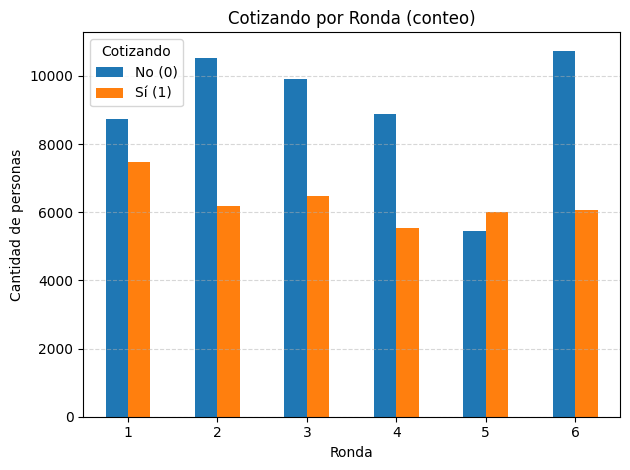

In [12]:
# Asegurarse que 'time' y 'cotizando' están bien tipados
df['time'] = df['time'].astype(int)
df['cotizando'] = df['cotizando'].astype('Int64')  # permite NaN en enteros

# Agrupar y contar
conteo = df.groupby(['time', 'cotizando']).size().unstack(fill_value=0)

# Graficar
conteo.plot(kind='bar', stacked=False)
plt.title('Cotizando por Ronda (conteo)')
plt.xlabel('Ronda')
plt.ylabel('Cantidad de personas')
plt.legend(title='Cotizando', labels=['No (0)', 'Sí (1)'])
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Se puede ver que la cantidad de NaN de cierta forma parecen coincidir con el menos número de 'No' en la Ronda 5, por lo que los NaN serán reemplazados por 0.

Después del análisis de los NaN en cada ronda se toman las siguiente decisiones:

In [13]:
#Deciones Tomadas:

# Eliminar Ronda 1
df = df[df['time'] != 1]

# Eliminar variable sistema
df = df.drop(columns=['sistema'])

# Imputaciones necesarias

df['expectancy'] = df['expectancy'].fillna(df['expectancy'].median()) #No se elimina solamente porque después se requiere para el análisis
df['children'] = df['children'].fillna(df['children'].median())
df['exp'] = df['exp'].fillna(df['exp'].median())
df['edu'] = df['edu'].fillna(df['edu'].median())
df['cotizando'] = df['cotizando'].fillna(df['cotizando'].mode()[0])

# Eliminar solo las columnas con 100% de NaN en ronda 5
df = df.drop(columns=['region', 'assets'])

**Estadística Descriptiva**

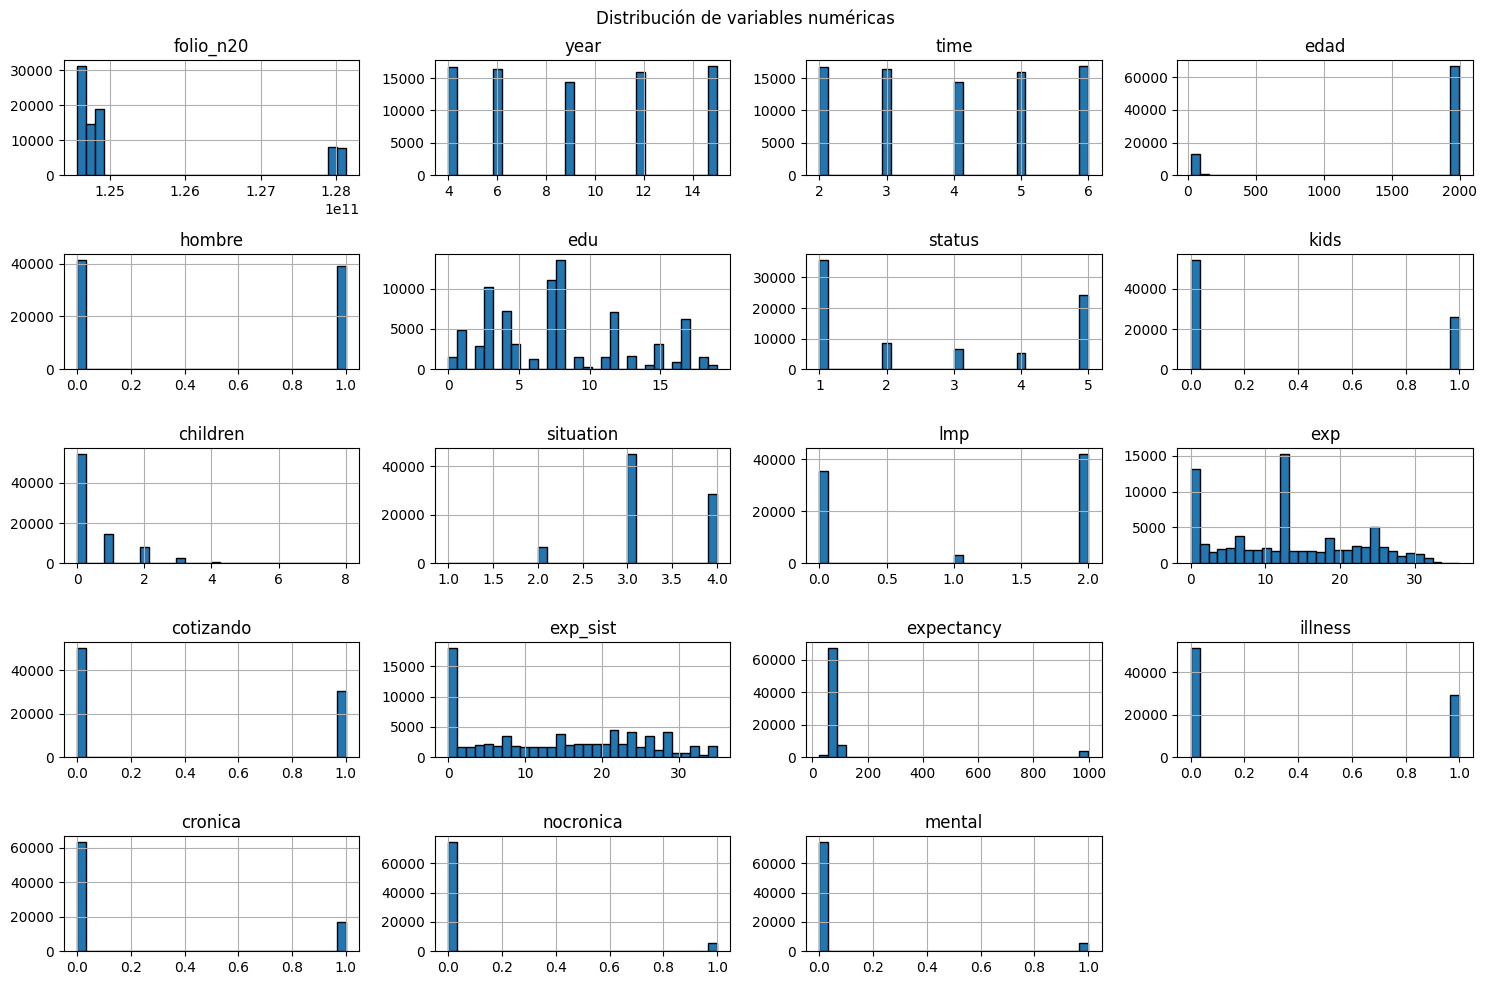

In [14]:
# Seleccionar solo columnas numéricas
numericas = df.select_dtypes(include='number')

# Histograma para cada variable
numericas.hist(bins=30, figsize=(15, 10), edgecolor='black')
plt.suptitle('Distribución de variables numéricas')
plt.tight_layout()
plt.show()

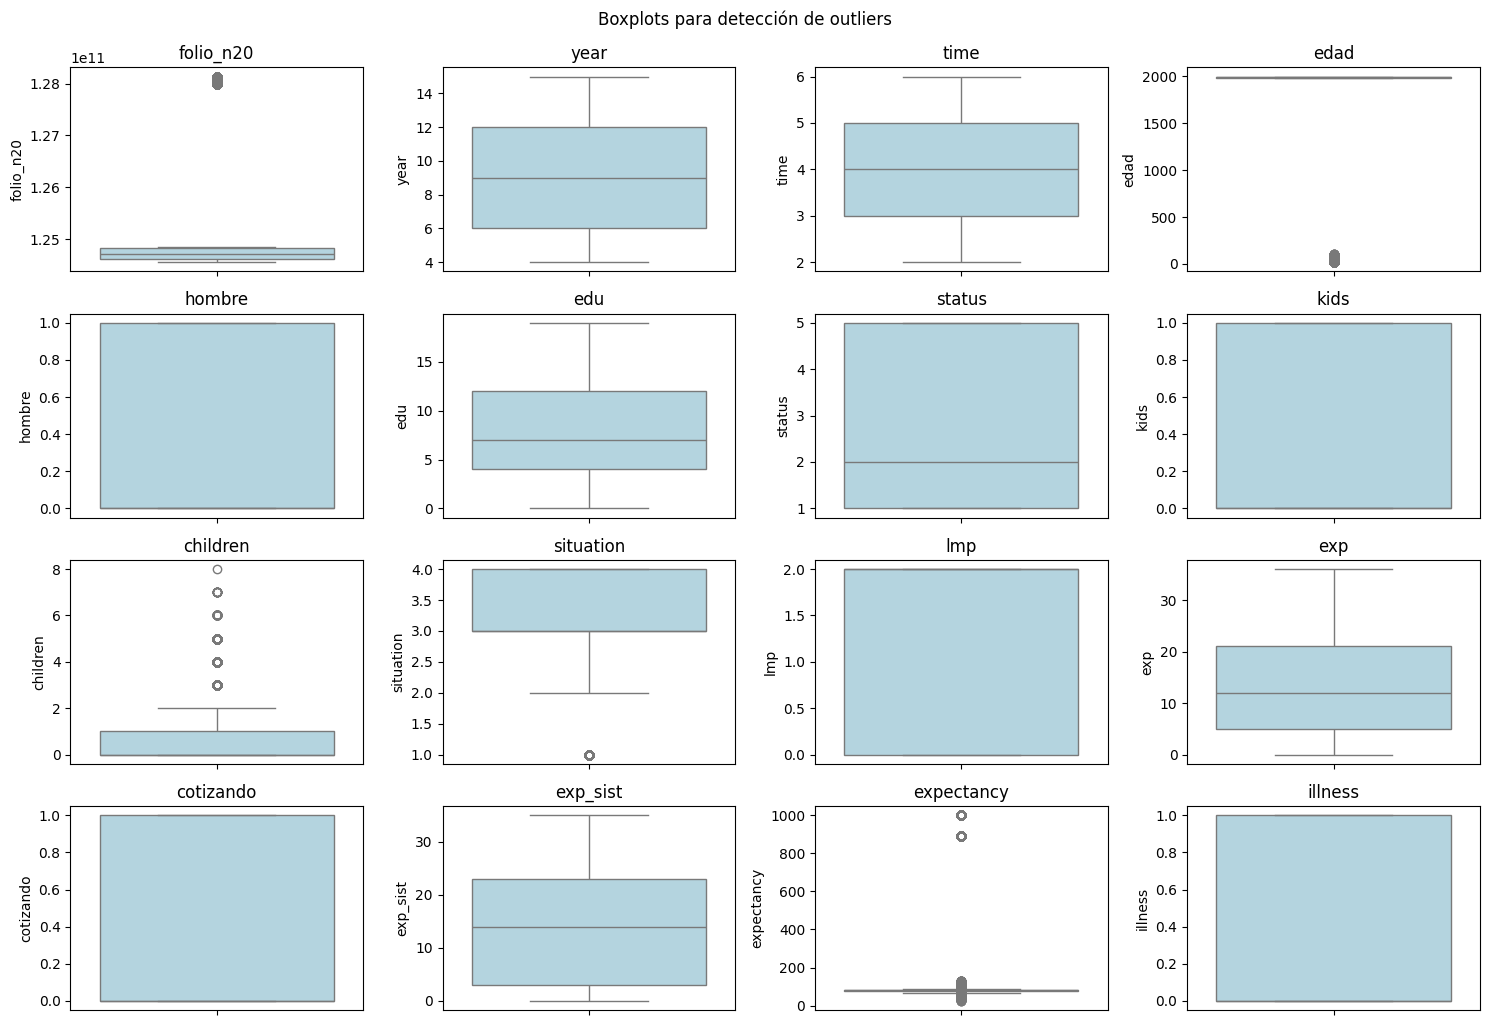

In [15]:
# Boxplot de cada variable numérica
plt.figure(figsize=(15, 10))
for i, col in enumerate(numericas.columns, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df[col], color='lightblue')
    plt.title(col)
    plt.tight_layout()
    if i==16:
        break
plt.suptitle('Boxplots para detección de outliers', y=1.02)
plt.show()

Se analizan los gráficos más a detalle de expectancy y edad, sin los outliers para mejorar su visualización. Además se busca visualizar valores representativos y la factibilidad de quitar los outliers extremos que no tengan sentido.

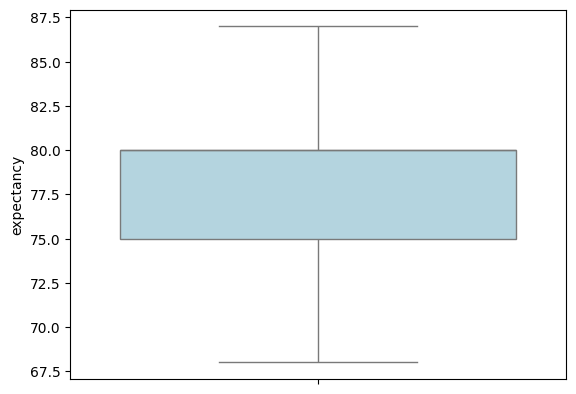

In [16]:
sns.boxplot(y=df['expectancy'], showfliers=False, color='lightblue')
plt.show()

Nos quitamos los outliers extremos de expectancy

In [17]:
df = df[df['expectancy'] < 150] #Límite teorico sugerido por organismos internacionales.

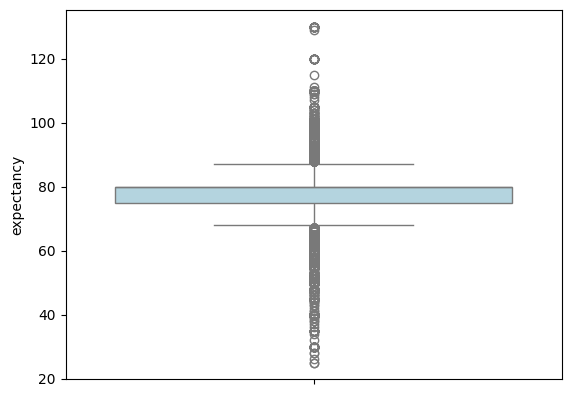

In [18]:
sns.boxplot(y=df['expectancy'], showfliers=True, color='lightblue')
plt.show()

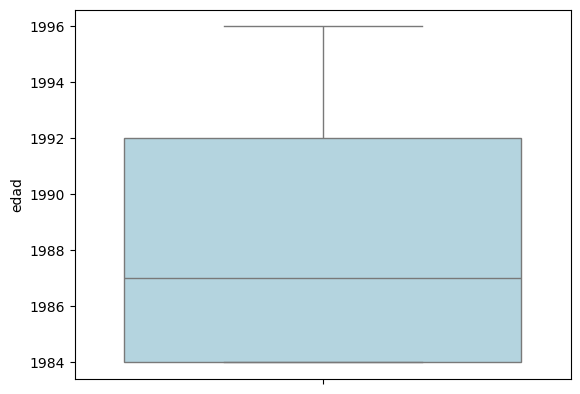

In [19]:
sns.boxplot(y=df['edad'], showfliers=False, color='lightblue')
plt.show()

Nos percatamos de un posible error en la toma de datos de edad.

In [20]:
df_filtro = df[df['edad'] < 500]
df_filtro.shape

(12637, 19)

In [21]:
df_filtro.value_counts('time')

time
2    3225
3    2931
5    2552
6    2284
4    1645
Name: count, dtype: int64

In [22]:
df = df.drop(columns=['edad'])

En la variable Edad se cometió un error sistemático en todas las rondas, en ocasiones se obtenía el año de nacimiento (en la mayoría de los casos), pero en un número de menor de ellos, se obtuvo la edad de la persona, por lo que los datos no son interesantes de analizar en general por la forma en la que se obtuvieron.

Se obtuvo la Matriz de correlación con las variables faltantes.

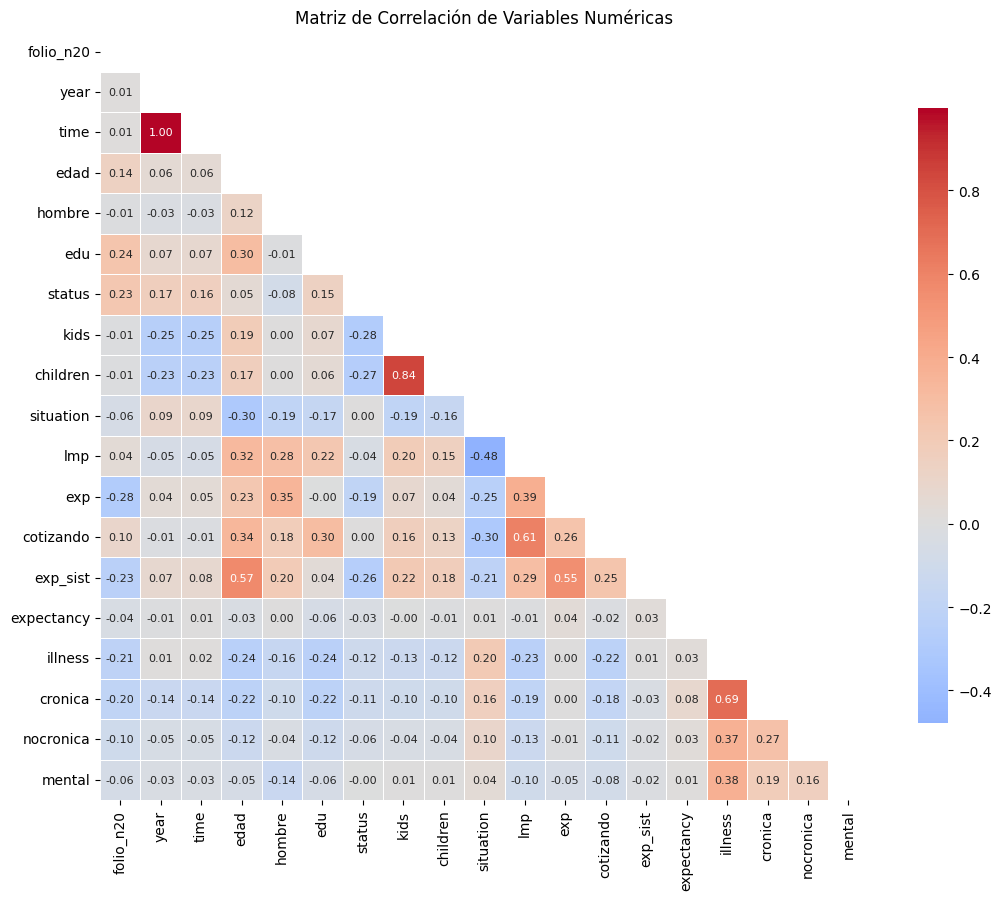

In [23]:
# Matriz de correlación
corr = numericas.corr()

# Crea la máscara para ocultar la mitad superior
mask = np.triu(np.ones_like(corr, dtype=bool))

# Establece tamaño del gráfico y el color
f, ax = plt.subplots(figsize=(11, 9))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Heatmap
sns.heatmap(corr, annot=True, mask=mask, fmt=".2f", cmap='coolwarm', center=0,
            square=True, linewidths=0.5, annot_kws={'size': 8}, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación de Variables Numéricas')
plt.tight_layout()
plt.show()

In [24]:
# Correlaciones altas
umbral = 0.7
correlaciones_altas = corr[(abs(corr) > umbral) & (abs(corr) < 1.0)]
print(correlaciones_altas.dropna(how='all').dropna(axis=1, how='all'))


              year      time      kids  children
year           NaN  0.997504       NaN       NaN
time      0.997504       NaN       NaN       NaN
kids           NaN       NaN       NaN  0.843668
children       NaN       NaN  0.843668       NaN


No se va a tomar en cuenta la variable year para el análisis, dada su estrecha relación con time. Y para las variables kids y children se tendrá en cuenta no usar las dos en simultaneo.

In [25]:
df = df.drop(columns=['year'])

Finalmente nos deshacemos de los NaN restantes.

In [26]:
df.shape

(76364, 17)

In [27]:
df.dropna(inplace=True)
df.reset_index(drop=True)
#Los NaN restantes son menos del 0.5% de los datos, un buen indicio.

,folio_n20,time,hombre,edu,status,kids,children,situation,lmp,exp,cotizando,exp_sist,expectancy,illness,cronica,nocronica,mental
0,124560204870,2,0.0,7.0,3.0,1,1.0,4,0,12.0,0,0,58.0,1.0,0.0,1.0,0.0
1,124560204870,3,0.0,4.0,3.0,1,1.0,4,0,12.0,0,0,55.0,0.0,0.0,0.0,0.0
2,124560204870,4,0.0,5.0,3.0,1,1.0,4,0,12.0,0,0,70.0,1.0,0.0,0.0,1.0
3,124560204870,5,0.0,4.0,5.0,0,0.0,3,1,12.0,0,0,70.0,1.0,0.0,0.0,0.0
4,124560205935,2,0.0,15.0,3.0,1,3.0,4,0,6.0,0,21,70.0,1.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76088,128133653188,5,0.0,16.0,3.0,0,0.0,4,0,12.0,0,7,80.0,0.0,0.0,0.0,0.0
76089,128133692735,5,0.0,12.0,2.0,0,0.0,3,2,12.0,1,7,80.0,1.0,0.0,0.0,0.0
76090,128133702320,5,0.0,15.0,5.0,0,0.0,4,0,12.0,1,7,75.0,0.0,0.0,0.0,0.0
76091,128133728022,5,0.0,8.0,2.0,0,0.0,3,2,12.0,1,6,70.0,1.0,0.0,0.0,0.0


## 2. Ejecute un modelo Pooled OLS para estimar la relación entre los años de educación y la expectativa de vida. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

Dada la librería que vamos a usar, para PanelOLS de linearmodels, se requiere que el DataFrame tenga un índice jerárquico (MultiIndex) con dos niveles, por lo que en primera instancia se definirá este índice:

In [28]:
df = df.set_index(['folio_n20','time'])

In [29]:
df['time'] = df.index.get_level_values('time')

Además se pasaran las variables integer a float para no tener problemas con los modelos más adelante.

In [30]:
df = df.convert_dtypes()
df = df.astype({col: "float64" for col in df.select_dtypes("integer").columns})

Ejecutamos el modelo Pooled OLS

En el tendremos en cuenta las siguientes variables (columnas) para todos los análisis posteriores:
- edu (nos sirve para analizar nuestra principal hipótesis, como afecta la educación a la expectativa de vida autorreportada). 
- children (usualmente familias con un alto número de hijos, suelen distribuir los ingresos en un mayor número de personas en el hogar, por lo que podría ver limitadas sus oportunidades en la vida tanto en salud, como educación, conllevando mayores cargas económicas asociadas a la crianza y al estrés asociado, y por ende tener una expectativa de vida menor). 
- exp (personas con más experiencia laboral, podrían percibir mayores ingresos, además de tener una edad más avanzada, por ende tener una expectativa de vida mayor) 
- time (variable temporal necesaria para el análisis posterior, un avance en las rondas, podría conllevar un aumento en la expectativa de vida al ir pasando los años, dado un desarrollo de la sociedad en tema de salud y bienestar).
- situation (personas cesantes por ejemplo, podrían tener una peor calidad de vida, y una expectativa de vida menor). 
- illness (personas con mayor número de enfermedades, podrían tener una peor calidad de vida, y una expectativa de vida menor). 
- cronica (personas con enfermedades crónicas, podrían tener una peor calidad de vida, y una expectativa de vida menor). 
- mental (personas con trastornos de salud mental, podrían tener una peor calidad de vida, y una expectativa de vida menor). 
- status (un entorno familiar que brinde mayor apoyo social y emocional (caso de personas casadas o que conviven), podrían tener impacto en la calidad de vida, y una expectativa de vida mayor). 
- cotizando (personas que estén cotizando, podrían tener una esperanza de mejores condiciones para su vejez, y por ende una expectativa de vida mayor). 

Mantendremos estas variables en los siguientes análisis para poder realizar comparaciones.

In [31]:
#Pasamos variables categoricas a su tipo correspondiente.

df['time'] = df['time'].astype('category')
df['hombre'] = df['hombre'].astype('category')
df['status'] = df['status'].astype('category')
df['kids'] = df['kids'].astype('category')
df['situation'] = df['situation'].astype('category')
df['lmp'] = df['lmp'].astype('category')
df['cotizando'] = df['cotizando'].astype('category')
df['illness'] = df['illness'].astype('category')
df['cronica'] = df['cronica'].astype('category')
df['nocronica'] = df['nocronica'].astype('category')
df['mental'] = df['mental'].astype('category')


y = df['expectancy']

X = pd.concat([
    df.drop(['time','hombre','situation','illness','cronica', 'mental','status','kids','lmp','expectancy','cotizando','nocronica','exp_sist'],axis=1),
    pd.get_dummies(df[['time','situation','illness','cronica','mental','status','cotizando']], drop_first=True, dtype=float),
], axis=1)

X = sm.add_constant(X)
model = lmp.PanelOLS(y, X)
mco = model.fit()
print(mco)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0410
Estimator:                   PanelOLS   R-squared (Between):              0.0427
No. Observations:               76093   R-squared (Within):               0.0283
Date:                Tue, May 20 2025   R-squared (Overall):              0.0410
Time:                        23:31:47   Log-likelihood                -2.697e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      180.82
Entities:                       32145   P-value                           0.0000
Avg Obs:                       2.3672   Distribution:                F(18,76074)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             180.82
                            

Primero que nada, a modo de mostrar el alcance del análisis, el modelo presenta un R² de tan solo 0.041, por ende los resultados obtenidos del modelo tienen sus limitaciones, que tal vez en un análisis más profundo o con modelos más adecuados puedan ser compensados. 
Igualmente los resultados del modelo sugieren, lo siguiente por variable:

- edu: Variable no significativa (por lo que podría no ser relevante para el estudio de la expectativa de vida).
- children: Significativa, por cada niño la expectativa de vida disminuye en 0.7520 años.
- exp: Significativa, por cada año de experiencia laboral la expectativa de vida aumenta en 0.0349 años.
- time: Todas las rondas son significativas, y pareciera que con el paso de las rondas fue aumentando la expectativa de vida, lo que en general es esperable por el desarrollo continuo de los países.
- situation: Solamente es significativo la 2da situación, donde ser cesante disminuye la expectativa de vida en 1.6312 años.
- illness: Significativa, donde tener alguna enfermedad disminuye la expectativa de vida en 0.9286 años.
- cronica: Significativa, donde tener alguna enfermedad crónica aumenta la expectativa de vida en 0.8313 años, posiblemente asociado a que las personas mayores suelen presentar más frecuentemente enfermedades crónicas.
- mental: Significativa, donde tener alguna enfermedad mental disminuye la expectativa de vida en 1.2940 años.
- status: Significativas, donde solamente ser viudo aumenta la expectativa de vida en 2.3012 años, posiblemente asociado a que las personas mayores suelen ser más frecuentemente vidas. 
- cotizando: Significativa, donde tener estar cotizando en el sistema de pensiones aumenta la expectativa de vida en 0.4068 años.

La mayoría de las hipótesis planteadas inicialmente parecieran concordar con la data, esto se podrá seguir viendo en los siguientes modelos.

## 3. Ejecute un modelo efectos fijos para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

Ejecutamos el modelo de efectos fijos.

In [32]:
model=lmp.PanelOLS(y,X, entity_effects=True, drop_absorbed=True)
fe=model.fit(cov_type="robust")
print(fe)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0383
Estimator:                   PanelOLS   R-squared (Between):             -0.0148
No. Observations:               76093   R-squared (Within):               0.0383
Date:                Tue, May 20 2025   R-squared (Overall):              0.0078
Time:                        23:31:47   Log-likelihood                -2.412e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      97.242
Entities:                       32145   P-value                           0.0000
Avg Obs:                       2.3672   Distribution:                F(18,43930)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             89.482
                            

Seguimos teniendo un R² bajo, de 0.0383. Igualmente los resultados del modelo sugieren, lo siguiente por variable:

- edu: Variable significativa al 5%, con signo negativo. Esto sugiere que a mayor nivel educativo, menor expectativa de vida, lo cual no es consistente con la literatura ni con el sentido común, y puede deberse a problemas asociados al modelo.
- children: Significativa. Por cada hijo adicional, la expectativa de vida disminuye en 0.3102 años, lo cual podría relacionarse con el estrés o cargas económicas asociadas a la crianza.
- exp: Significativa. A igual que el primer modelo, indica que un año más de experiencia laboral, aumenta la expectativa de vida en 0.1072 años.
- time (rondas): Todas las variables asociadas a las rondas 3 a 6 son significativas. Se mantiene la tendencia creciente: con el paso del tiempo, la expectativa de vida aumenta, lo cual es esperable y coincide con avances en salud pública, condiciones de vida, etc.
- situation: Las situaciones 2 (cesante), 3 (trabajando) y 4 (inactivo) son todas significativas, y reducen la expectativa de vida, siendo más notorio que en el anteior modelo (con coeficientes negativos de -2.6103, -2.4652 y -2.7133 respectivamente).
- illness: Significativa. Tener una enfermedad reduce la expectativa de vida en 0.7390 años, lo cual es coherente con lo esperado.
- cronica: Significativa. Tener una enfermedad crónica aumenta la expectativa de vida en 0.3465 años, lo cual puede interpretarse como un efecto asociado a la edad, dado que las personas mayores (con mayor expectativa de vida en algunos contextos) tienden a acumular enfermedades crónicas.
- mental: No significativa. A diferencia del modelo anterior, no se encuentra una relación estadísticamente significativa entre tener una enfermedad mental y la expectativa de vida.
- status: Solamente viudo es significativo: pero ahora indicando una disminución de la expectativa de vida en -0.5253 años.
- cotizando: Significativa. Estar cotizando aumenta la expectativa de vida en 0.3960 años, lo que puede estar relacionado con una mayor estabilidad económica en el largo plazo.

Cabe destacar, que en este modelo hay varias variables no significativa, que podría deberse que el cambio en estas variables en un individuo podrían no afectar directamente su expectativa de vida autorreportada.

## 4. Ejecute un modelo de efectos aleatorios para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. 

Ejecutamos el modelo de efectos aleatorios

In [33]:
model=lmp.RandomEffects(y,X)
re=model.fit(cov_type="robust")
print(re)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.3033
Estimator:              RandomEffects   R-squared (Between):              0.0420
No. Observations:               76093   R-squared (Within):               0.0300
Date:                Tue, May 20 2025   R-squared (Overall):              0.0408
Time:                        23:31:48   Log-likelihood                -2.644e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      1840.3
Entities:                       32145   P-value                           0.0000
Avg Obs:                       2.3672   Distribution:                F(18,76074)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             263.75
                            

Ahora tenemos un R^2 mucho más alto, de 0.3033 lo que podría indicar un mejor ajuste del modelo. Los resultados del modelo sugieren, lo siguiente por variable:

- edu: No significativa (p = 0.3626). Esto indica que el nivel educativo no muestra una relación estadísticamente confiable con la expectativa de vida dentro del modelo.
- children: Significativa. Cada hijo adicional disminuye la expectativa de vida en 0.7562 años, lo que podría reflejar mayor carga económica o emocional.
- exp: Significativa. Misma conclusión los años laborales aumentan la expectativa de vida en 0.0326 años.
- time (rondas 3 a 6): Todas las rondas son significativas. Esto refleja que la expectativa de vida aumenta en cada ronda, lo cual es coherente con mejoras en salud, economía o condiciones sociales a lo largo del tiempo.
- situation: Solamente cesante es significativa (p = 0.0162), disminuye la expectativa de vida en 1.5408 años.
- illness: Significativa. Tener alguna enfermedad reduce la expectativa de vida en 0.8882 años.
- cronica: Significativa. Tener una enfermedad crónica aumenta la expectativa de vida en 0.8151 años, lo cual puede reflejar correlación con edad avanzada, como se mencionó en los modelos anteriores.
- mental: Significativa. Tener una enfermedad mental disminuye la expectativa de vida en 1.0854 años, resultado consistente con el primer modelo y con la literatura.
- status: Todas significativas, solamente ser viudo, aumenta la expectativa de vida en 2.1501 años, posiblemente por razones de edad.
- cotizando: Significativa. Estar cotizando aumenta la expectativa de vida en 0.3442 años, coherente con acceso a beneficios o salud financiera.

In [34]:
re.variance_decomposition

Effects                    6.989861
Residual                  57.444343
Percent due to Effects     0.108481
Name: Variance Decomposition, dtype: float64

La descomposición de varianza del modelo de efectos aleatorios indica que la mayor parte de la variabilidad en la variable dependiente (expectativa de vida) proviene del término residual (57.44), mientras que una proporción mucho menor se debe a los efectos aleatorios entre unidades (6.99). Esto se traduce en que solo el 10.85% de la varianza total es atribuible a diferencias sistemáticas entre los grupos (por ejemplo, individuos, regiones o unidades agrupadas, según cómo se haya definido el efecto aleatorio), mientras que el 89.15% restante corresponde a diferencias no explicadas dentro de los grupos o al azar. En términos prácticos, esto sugiere que la heterogeneidad entre las unidades agrupadas tiene un papel limitado en explicar la variación de la expectativa de vida.

Este resultado implica que la mayor parte de la variabilidad está ocurriendo dentro de los grupos más que entre ellos, lo que pone en cuestión la relevancia de incluir efectos aleatorios en el modelo. Si bien el modelo de efectos aleatorios permite capturar diferencias no observadas entre grupos, en este caso su contribución explicativa es marginal, y podría ser más eficiente usar un modelo con efectos fijos o incluso un modelo de regresión simple, si la estructura de datos lo permite. En resumen, aunque hay cierta variación atribuible a los efectos aleatorios, su magnitud es baja, por lo que la agrupación no parece ser un factor determinante en la variable dependiente bajo estudio.

## 5. Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

In [35]:
print(lmp.compare({"FE": fe, "RE": re, "Pooled": mco}))

                            Model Comparison                           
                                    FE                RE         Pooled
-----------------------------------------------------------------------
Dep. Variable               expectancy        expectancy     expectancy
Estimator                     PanelOLS     RandomEffects       PanelOLS
No. Observations                 76093             76093          76093
Cov. Est.                       Robust            Robust     Unadjusted
R-squared                       0.0383            0.3033         0.0410
R-Squared (Within)              0.0383            0.0300         0.0283
R-Squared (Between)            -0.0148            0.0420         0.0427
R-Squared (Overall)             0.0078            0.0408         0.0410
F-statistic                     97.242            1840.3         180.82
P-value (F-stat)                0.0000            0.0000         0.0000
=====================     ============   ===============   =====

Al comparar los tres modelos, **Pooled OLS**, **efectos fijos (FE)** y **efectos aleatorios (RE)**, podemos observar diferencias sustanciales en su capacidad para explicar la variabilidad de la expectativa de vida y en la significancia de ciertas variables. El modelo Pooled OLS, presenta un R² bajo (0.041), lo que indica una baja capacidad explicativa total. El modelo de efectos fijos logra un R² similar (0.0383), pero se enfoca en la variación dentro de las unidades a lo largo del tiempo, lo cual puede ser más relevante en estudios de panel. Por otro lado, el modelo de efectos aleatorios muestra un R² sustancialmente mayor (0.3033), lo que sugiere que es el que mejor capta tanto las diferencias entre como dentro de las unidades. Esta diferencia también se respalda en su mayor estadístico F (1840.3), lo que indica que el modelo en conjunto es estadísticamente más significativo que los otros dos.

En cuanto a la significancia de las variables, algunas muestran estabilidad entre modelos (como children, exp, time, illness, cronica y cotizando, todas altamente significativas en los tres, manteniendo el mismo sentido y siendo robustas ante el cambio de modelos), mientras que otras cambian notablemente su relevancia según la estructura del modelo. Por ejemplo, la variable edu solo es significativa en el modelo FE, y su signo cambia (positivo en Pooled y RE, negativo en FE), lo que puede indicar confusión o efectos no observados capturados por los efectos fijos. Variables como mental también muestran cambios importantes, en OLS y RE se asocia fuertemente con la expectativa de vida, pero en FE su significancia se reduce. En las variables correspondientes a status, podemos notar como todas son significativas en los modelos OLS y RE, pero para el modelo FE, solamente el status viudo es significativo, esto nos estaría sugiriendo que tal vez las personas al quedarse viudos ven disminuida su expectativa de vida con respecto a la que tenían antes de quedar viudos, asimismo igualmente presentan un expectativa de vida más alta que el resto de los status como se puede apreciar en los otros modelos. Además, cabe rescatar que los demás status podrían no ver tan alterada su expectativa de vida al cambiar a este status, o simplemente no cambia tanto en los individuos durante los años. Finalmente, la última variable a analizar es el situation donde ser cesante en todos los modelos parece indicar que disminuye la expectativa de vida, pero para las otras situation no es significativa en RE, aunque si para FE, lo que nuevamente podría indicar que cambiar a esta situation podría cambiar la expectativa de vida autorreportada por cada individuo. 

Dado que la descomposición de varianza del modelo RE mostró que solo el 10.85% de la varianza proviene de los efectos aleatorios, se podría argumentar que el modelo FE es más adecuado si se quiere evitar supuestos sobre la independencia entre los efectos individuales y los regresores. Sin embargo, el RE ofrece mejor ajuste global. La elección final depende del objetivo analítico: inferencia causal precisa (FE) o mejor predicción general (RE), igualmente se realizará un test de Durbin-Wu-Hausman para comprobar esta hipótesis.

In [36]:
import numpy.linalg as la
from scipy import stats

def hausman(fe, re):
 diff = fe.params-re.params
 psi = fe.cov - re.cov
 dof = diff.size -1
 W = diff.dot(la.inv(psi)).dot(diff)
 pval = stats.chi2.sf(W, dof)
 return W, dof, pval

htest = hausman(fe, re) 
print("Hausman Test: chi-2 = {0}, df = {1}, p-value = {2}".format(htest[0], htest[1], htest[2]))

Hausman Test: chi-2 = 473.56019466476056, df = 18, p-value = 3.730890563006e-89


El test de Hausman sirve para decidir entre dos modelos: efectos fijos (FE) o efectos aleatorios (RE). Lo que hace es comparar los coeficientes de ambos modelos y ver si hay evidencia de que los efectos individuales (las diferencias entre personas) están correlacionados con las variables explicativas. En este caso, como el p-valor es mucho menor que 0.05, rechazamos la hipótesis nula del test, esto quiere decir que los efectos individuales sí están correlacionados con las variables explicativas (como la educación). Por lo tanto, el modelo de efectos aleatorios (RE) no es apropiado, porque su supuesto clave se rompe.

Tras comparar los tres modelos estimados (Pooled OLS, efectos fijos y efectos aleatorios), y considerando tanto los resultados del test de Durbin-Wu-Hausman como la significancia y estabilidad de las variables, se determina que el modelo de efectos fijos es el más adecuado para analizar la relación entre la educación y la expectativa de vida. Este modelo permite controlar por características individuales no observadas que podrían estar influyendo en ambas variables, y evita el sesgo que podría introducirse al asumir, incorrectamente, que dichas características no están correlacionadas con los regresores, como lo hace el modelo de efectos aleatorios. Por lo tanto, si el objetivo es obtener una estimación robusta y confiable del impacto de la educación sobre la expectativa de vida, el enfoque de efectos fijos ofrece la mayor validez estadística y conceptual.

## 6. Ejecute un modelo de efectos aleatorios correlacionados (CRE) para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. Es este modelo adecuado, dada la data disponible, para modelar el componente no observado?

In [37]:
df['situation'] = df['situation'].astype('float64')
df['kids'] = df['kids'].astype('float64')
df['cotizando'] = df['cotizando'].astype('float64')
df['illness'] = df['illness'].astype('float64')
df['cronica'] = df['cronica'].astype('float64')
df['mental'] = df['mental'].astype('float64')
df['status'] = df['status'].astype('float64')

X = df.drop(['expectancy','time','kids','lmp','nocronica','exp_sist','hombre'], axis=1, inplace=False)

Xm = X.groupby(by = 'folio_n20').transform('mean')
Xm.columns = ['m{}'.format(column) for column in Xm.columns]

Xc = pd.merge(df,Xm, left_index=True, right_index=True)
Xc

y = Xc['expectancy']

df['situation'] = df['situation'].astype('category')
df['kids'] = df['kids'].astype('category')
df['cotizando'] = df['cotizando'].astype('category')
df['illness'] = df['illness'].astype('category')
df['cronica'] = df['cronica'].astype('category')
df['mental'] = df['mental'].astype('category')
df['status'] = df['status'].astype('category')

Xc['situation'] = Xc['situation'].astype('category')
Xc['kids'] = Xc['kids'].astype('category')
Xc['cotizando'] = Xc['cotizando'].astype('category')
Xc['illness'] = Xc['illness'].astype('category')
Xc['cronica'] = Xc['cronica'].astype('category')
Xc['mental'] = Xc['mental'].astype('category')
Xc['status'] = Xc['status'].astype('category')


X = pd.concat([
    Xc.drop(['time','hombre','situation','illness','cronica', 'mental','status','kids','lmp','expectancy','cotizando','nocronica','exp_sist'],axis=1),
    pd.get_dummies(Xc[['time','situation','illness','cronica','mental','status','cotizando']], drop_first=True, dtype=float),
], axis=1)

X=sm.add_constant(X)

model=lmp.RandomEffects(y,X) 
cre=model.fit(cov_type="robust")
print(cre)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.3064
Estimator:              RandomEffects   R-squared (Between):              0.0429
No. Observations:               76093   R-squared (Within):               0.0344
Date:                Tue, May 20 2025   R-squared (Overall):              0.0452
Time:                        23:31:49   Log-likelihood                -2.643e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      1244.8
Entities:                       32145   P-value                           0.0000
Avg Obs:                       2.3672   Distribution:                F(27,76065)
Min Obs:                       1.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             184.13
                            

El modelo de **Efectos Aleatorios Correlacionados (CRE)**, nos permite evaluar la influencia de variables individuales observadas y no observadas, controlando por la correlación entre efectos individuales y las variables explicativas. En este caso, se incorporaron promedios a nivel de individuo para detectar esta posible correlación de las variables: edu, status, children, situation, exp, cotizando, illness, cronica y mental. A diferencia del modelo RE, el CRE no asume independencia entre las variables explicativas y los efectos individuales, por lo que es una alternativa más flexible y robusta que nos podría ayudar en este caso dado el análisis anterior.

Los resultados del modelo CRE muestran un R² de 0.3064, mayor que el de los modelos Pooled OLS (0.0410), FE (0.0383), y RE (0.3033), lo que sugiere que este modelo explica mejor la variabilidad de la expectativa de vida. La mayoría de las variables son significativas: por ejemplo, edu indica que, por cada año de educación, la expectativa de vida disminuye en 0.0431 años, por lo tanto nos da una conclusión parecida al modelo FE. El promedio de educación a nivel individual (medu) es significativo y positivo, aunque esta magnitud no es sujeto de análisis en este momento. Además, muchas otras variables muestran significancia y sentido esperado (por ejemplo, experiencia laboral, enfermedades mentales, estar cotizando, tener hijos, etc.). Este modelo logra capturar tanto los efectos entre personas como dentro de cada persona a través del tiempo, por lo que entrega una visión más completa y matizada del fenómeno estudiado. En conjunto, el modelo CRE solamente presenta como variables no significativas cronica, y las medias de status y cotizando, por lo que parece ofrecer una mejora importante en precisión y robustez frente a las demás alternativas evaluadas.

## 7. Usando el modelo CRE, prediga la distribución del componente no observado. Que puede inferir respecto de la heterogeneidad fija en el tiempo y su impacto en la expectativa de vida?

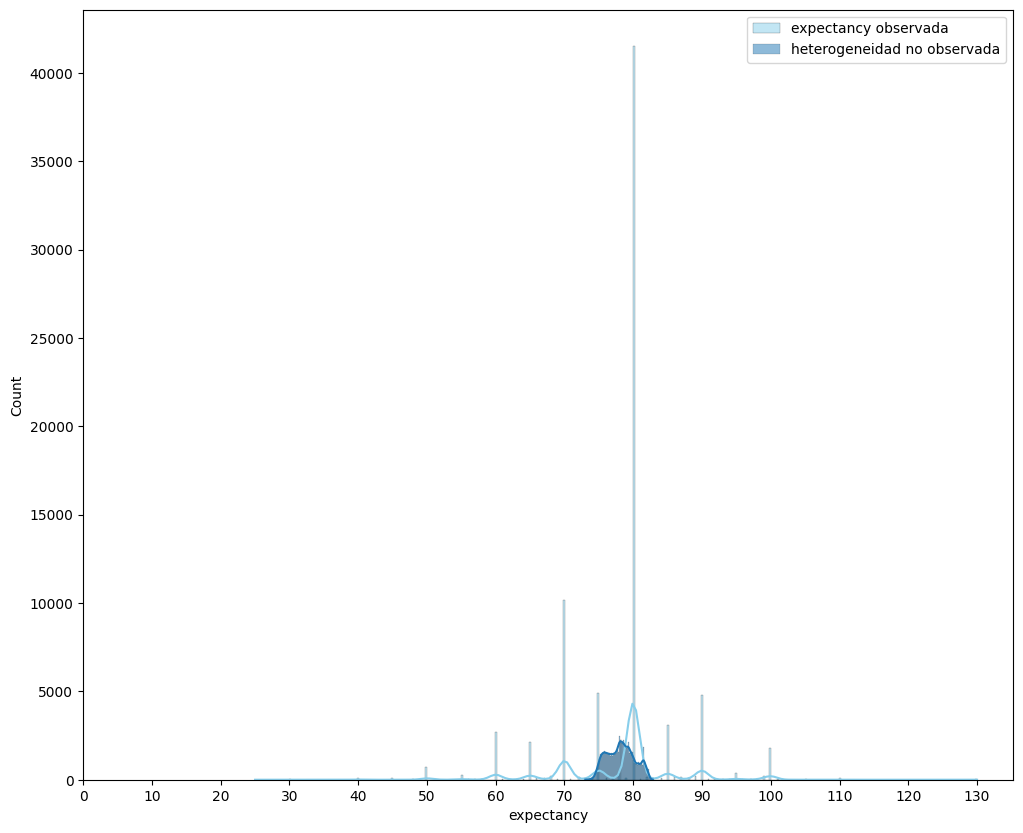

In [38]:
Xpred = X
Xpred['edu']=0
Xpred['children']=0
Xpred['exp']=0
Xpred['time_3.0']=0
Xpred['time_4.0']=0
Xpred['time_5.0']=0
Xpred['time_6.0']=0
Xpred['situation_2.0']=0
Xpred['situation_3.0']=0
Xpred['situation_4.0']=0
Xpred['illness_1.0']=0
Xpred['cronica_1.0']=0
Xpred['mental_1.0']=0
Xpred['status_2.0']=0
Xpred['status_3.0']=0
Xpred['status_4.0']=0
Xpred['status_5.0']=0
Xpred['cotizando_1.0']=0
yhat = cre.predict(Xpred)

plt.figure(figsize=(12, 10))

sns.histplot(data=y, color="skyblue", label="expectancy observada", kde=True)
sns.histplot(data=yhat, color="red", label="heterogeneidad no observada", kde=True)
plt.xticks(np.arange(0, 140, step=10))
plt.legend() 
plt.show()

El gráfico muestra dos distribuciones: la observada de la expectativa de vida autorreportada y la heterogeneidad no observada obtenida al fijar en cero las variables explicativas originales de los modelos (sin tomar en cuenta las medias obtenidas). La distribución observada (en celeste) presenta una gran concentración en torno a los 80 años, con picos pronunciados que sugieren valores discretos, lo que sería explicado por las respuestas más comunes en torno a multiplos de 10 o 5. Por otro lado, la distribución de la heterogeneidad no observada (en azul oscuro) es mucho más suave y se concentra también en la zona de 75 a 85 años, pero con menor varianza y sin los picos abruptos de la distribución observada. Ambas distribuciones parecieran estar concentradas en la misma zona, esta última más oscura levemente a la izquierda, pero aún así bastante centrada con respecto al área más clara.

Esto sugiere que una parte importante de la variación en la expectativa de vida está asociada a factores no observables que son constantes en el tiempo para cada individuo, es decir, heterogeneidad fija en el tiempo. La forma más concentrada y simétrica de esta distribución indica que, aunque existen diferencias individuales inobservables que afectan la expectativa de vida, estas diferencias no generan una dispersión tan grande como la que se observa en los datos reales, donde influyen factores observables. Por tanto, el modelo CRE permite identificar que una parte relevante de la variación en la expectativa de vida está ligada a características individuales persistentes, cuyo efecto no cambia a lo largo del tiempo.

## 8. Usando sus respuestas anteriores, que modelo prefiere? que se puede inferir en general respecto del efecto de las variables explicativas sobre la expectativa de vida?

In [39]:
print(lmp.compare({"FE": fe, "RE": re, "CRE": cre}))

                             Model Comparison                             
                                    FE                RE               CRE
--------------------------------------------------------------------------
Dep. Variable               expectancy        expectancy        expectancy
Estimator                     PanelOLS     RandomEffects     RandomEffects
No. Observations                 76093             76093             76093
Cov. Est.                       Robust            Robust            Robust
R-squared                       0.0383            0.3033            0.3064
R-Squared (Within)              0.0383            0.0300            0.0344
R-Squared (Between)            -0.0148            0.0420            0.0429
R-Squared (Overall)             0.0078            0.0408            0.0452
F-statistic                     97.242            1840.3            1244.8
P-value (F-stat)                0.0000            0.0000            0.0000
=====================    

Al comparar los modelos de Efectos Fijos (FE), Efectos Aleatorios (RE) y Efectos Aleatorios Correlacionados (CRE), se observa que el modelo CRE presenta el mejor ajuste estadístico, con un R² más alto (0.3064) que FE (0.0383) y RE (0.3033). Además, al haber encontrado evidencia de correlación entre los efectos individuales no observados y las variables explicativas (según el test de Hausman), se descarta el modelo RE por inconsistente. Aunque el modelo FE es consistente bajo estas condiciones, su baja capacidad explicativa y la imposibilidad de estimar efectos de variables invariantes en el tiempo lo hacen menos informativo. En cambio, el modelo CRE corrige el sesgo del RE y permite incluir variables a nivel promedio individual, lo que ofrece una visión más completa del fenómeno analizado.

Analizando con mayor detalle las diferencias de los resultados entre los modelos estudiados, podemos inferir que existen varias variables significativas y robustas entre los modelos, como lo son children, exp, time, situation (menos situation inactivo que en el modelo RE no es significativa), illness y cotizando. De estas variables robustas remontandonos a la hipotetización inicial, podemos confirmar según la data disponible que a mayor número niños se obtiene una expectativa de vida menor, posiblemente debido las mayores cargas económicas asociadas a la crianza y al estrés que conlleva. También ha mayor experiencia laboral, se experimenta una mayor expectativa de vida, esto ligado a que las personas con más experiencia laboral, podrían percibir mayores ingresos, además de tener una edad más avanzada, y por ende tener una expectativa de vida mayor. Asimismo, personas que enfermedades tienen una expectativa de vida menor, dado por una menor calidad de vida en general. En temas de cotización, se pudo ver que personas que esten cotizando, podrían tener una esperanza de mejores condiciones para su vejez, y por ende una expectiva de vida mayor. Y desde la situación de trabajo en la que se encuentre la persona, influye en la expectativa de vida, donde por ejemplo personas cesantes, podrían tener una peor calidad de vida, y una expectiva de vida menor. Por último, el tiempo (las rondas), se observo que al ir avanzando a su vez iba aumentando la expectativa de vida, posiblemente influenciado por un mayor desarrollo en temas de salud y bienestar. 

Siguiendo con el análisis, podemos destacar que en temas de educación, nuestro principal foco, tanto los modelos FE como CRE (los que presentaban mejores resultados), nos indican que ante un mayor nivel de educación, se tiene una disminución en la expectativa de la vida, lo que para algunas personas podría ser contraintuitivo dado que este mayor nivel de educación esta asociado a mejores condiciones de vida y por ende una mejor expectativa de vida, pero también se podría explicar el resultado tomando en cuenta de que las generaciones más jóvenes cada vez tienen mejor educación y estudian durante una mayor cantidad de años, por lo que los resultados obtenidos podrían venir de esta asociación. Finalmente cabe recalcar que algunas variables fueron no significativas para FE, como mental y status, mientras que para los otros modelos si eran significativas, y cronica es la única variable fuera de los promedios, que no fue significativa en el modelo CRE.

## 9. Bonus track (optativo): Es posible que sus resultados anteriores tengan sesgo dado que quienes esperan vivir mas pueden estar incentivados a adquirir más educacion. Proponga AL MENOS DOS instrumentos posibles para predecir el nivel de educacion de forma exogena, tal que se pueda corregir el sesgo y entender el efecto causal de las educacion en la expectativa de vida. Realice su estimacion considerando un modelo agrupado (ignorando el tiempo), y el modelo de panel.

Para realizar esto, vamos a tomar en cuenta como variables exogenas la experiencia laboral y la cotización, para predecir el nivel de educación.

### Variables instrumentales

In [40]:
from statsmodels.api import add_constant

df2 = df

df = sm.add_constant(df)
res_ols = IV2SLS(df.expectancy, df[['children','time','illness','cronica','mental','status','situation','edu','const']], None, None).fit(
    cov_type="unadjusted")
res_IV = IV2SLS(df.expectancy, df[['children','time','illness','cronica','mental','status','situation','const']], df['edu'], df[['exp','cotizando']]).fit(
    cov_type="unadjusted")

from linearmodels.iv import compare
print(compare({"OLS": res_ols, "2SLS": res_IV}))

                  Model Comparison                 
                                OLS            2SLS
---------------------------------------------------
Dep. Variable            expectancy      expectancy
Estimator                       OLS         IV-2SLS
No. Observations              76093           76093
Cov. Est.                unadjusted      unadjusted
R-squared                    0.0395          0.0380
Adj. R-squared               0.0393          0.0378
F-statistic                  3131.7          3128.4
P-value (F-stat)             0.0000          0.0000
==================     ============    ============
children                    -0.7615         -0.7821
                          (-20.775)       (-20.662)
time.3.0                     0.9620          0.9444
                           (10.426)        (10.189)
time.4.0                     0.7491          0.7163
                           (7.1006)        (6.7178)
time.5.0                     1.6233          1.5562
            

En esta estimación agrupada (ignorando el panel), se presentan los resultados del modelo OLS y el modelo IV (2SLS), en donde se utiliza la variable edu como endógena. Para corregir el posible sesgo por endogeneidad, se emplean como instrumentos las variables exp (años de experiencia laboral) y cotizando (si la persona cotiza en el sistema de seguridad social). Los resultados muestran que el coeficiente de edu aumenta de 0.0152 en el modelo OLS a 0.0879 en el modelo IV, lo que sugiere que el efecto de la educación sobre la expectativa de vida estaba subestimado en la regresión OLS. Esto refuerza la hipótesis de que existe sesgo por causalidad inversa o variables omitidas, donde personas con mejor salud y mayor esperanza de vida también tienden a buscar mayor educación.

### Variables instrumentales con datos de panel

In [41]:
from fixedeffect.iv import iv2sls, ivgmm, ivtest
from fixedeffect.fe import fixedeffect

df2 = df2.loc[df.index.get_level_values('folio_n20') < 124610000000]
df2['folio_n20'] = df2.index.get_level_values('folio_n20')
df2['time'] = df2['time'].astype('float64')
df2['folio_n20'] = df2['folio_n20'].astype('float64')

cat_vars = ['children', 'illness', 'cronica','mental','status','situation','edu','cotizando']
for var in cat_vars:
    df2[var] = df2[var].astype('float64')
#Nos quedamos con 14.172 datos
df2

hombre   edu  status kids  children  situation  lmp   exp  \
folio_n20    time                                                             
124560204870 2       0.0   7.0     3.0  1.0       1.0        4.0  0.0  12.0   
             3       0.0   4.0     3.0  1.0       1.0        4.0  0.0  12.0   
             4       0.0   5.0     3.0  1.0       1.0        4.0  0.0  12.0   
             5       0.0   4.0     5.0  0.0       0.0        3.0  1.0  12.0   
124560205935 2       0.0  15.0     3.0  1.0       3.0        4.0  0.0   6.0   
...                  ...   ...     ...  ...       ...        ...  ...   ...   
124609984958 2       1.0  19.0     1.0  0.0       0.0        3.0  2.0  24.0   
             3       1.0  19.0     1.0  0.0       0.0        3.0  2.0  27.0   
             4       1.0  17.0     1.0  0.0       0.0        4.0  0.0  29.0   
             5       1.0   7.0     1.0  0.0       0.0        4.0  0.0  29.0   
             6       1.0  19.0     1.0  0.0       0.0        4.0  0.0  29.0   

                   cotizando  exp_sist  expectancy  illness  cronica  \
folio_n20    time                                                      
124560204870 2           0.0       0.0        58.0      1.0      0.0   
             3           0.0       0.0        55.0      0.0      0.0   
             4           0.0       0.0        70.0      1.0      0.0   
             5           0.0       0.0        70.0      1.0      0.0   
124560205935 2           0.0      21.0        70.0      1.0      1.0   
...                      ...       ...         ...      ...      ...   
124609984958 2           1.0      23.0        85.0      0.0      0.0   
             3           1.0      25.0        80.0      0.0      0.0   
             4           0.0      28.0        80.0      0.0      0.0   
             5           0.0      31.0        80.0      1.0      0.0   
             6           0.0      34.0        80.0      1.0      0.0   

                  nocronica  mental  time     folio_n20  
folio_n20    time                                        
124560204870 2          1.0     0.0   2.0  1.245602e+11  
             3          0.0     0.0   3.0  1.245602e+11  
             4          0.0     1.0   4.0  1.245602e+11  
             5          0.0     0.0   5.0  1.245602e+11  
124560205935 2          1.0     0.0   2.0  1.245602e+11  
...                     ...     ...   ...           ...  
124609984958 2          0.0     0.0   2.0  1.246100e+11  
             3          0.0     0.0   3.0  1.246100e+11  
             4          0.0     0.0   4.0  1.246100e+11  
             5          0.0     0.0   5.0  1.246100e+11  
             6          1.0     0.0   6.0  1.246100e+11  

[14172 rows x 17 columns]

In [42]:
formula = 'expectancy ~ children + illness + cronica + mental + status + situation + edu|folio_n20+time|folio_n20+time|0'

model_fe = fixedeffect(data_df = df2,
                       formula = formula,
                       no_print=True)

result = model_fe.fit()
print(result.params)
print(result.bse)

const        82.243246
children     -1.206799
illness      -0.775292
cronica       0.555390
mental       -0.404236
status       -0.202877
situation    -0.212507
edu          -0.088634
dtype: float64
const        0.514833
children     0.428104
illness      0.223957
cronica      0.459103
mental       0.385511
status       0.131665
situation    0.186366
edu          0.046261
Name: bse, dtype: float64


Aquí se estima un modelo con efectos fijos por individuo (folio_n20) que controla por características no observadas constantes en el tiempo. A diferencia del modelo agrupado, el coeficiente de edu resulta ser negativo (-0.0886) y marginalmente significativo. Este resultado puede estar influido por la baja variación de la educación dentro del individuo a lo largo del tiempo (dado que muchas personas mantienen su nivel educativo constante), lo que limita la capacidad del modelo para identificar su efecto real. Aun así, esta estimación permite controlar por heterogeneidad no observable entre individuos.

In [43]:
formula = 'expectancy ~ children + illness + cronica + mental + status + situation|folio_n20|0|(edu~exp + cotizando)'
model_iv2sls = iv2sls(data_df = df2, formula = formula)
result = model_iv2sls.fit()
print(result.params)
print(result.bse)

dependent variable(s): ['expectancy']
independent(exogenous): ['children', 'illness', 'cronica', 'mental', 'status', 'situation']
category variables(fixed effects): ['folio_n20']
cluster variables: ['0']
endogenous variables: ['edu']
instruments: ['exp', 'cotizando']
const        83.978031
children     -1.793172
illness      -0.526150
cronica       0.476384
mental       -0.341780
status       -0.039789
situation    -0.033835
hat_edu      -0.598297
dtype: float64
const        4.746857
children     0.210072
illness      0.230722
cronica      0.287566
mental       0.256606
status       0.115579
situation    0.133963
hat_edu      0.905062
dtype: float64


En este modelo se utiliza una especificación con efectos fijos y variables instrumentales, considerando edu como endógena y utilizando nuevamente exp y cotizando como instrumentos. El coeficiente estimado para edu es negativo (-0.5983) y no significativo, con un alto error estándar (0.9051). Esto indica que la estimación es poco precisa, probablemente debido a la debilidad de los instrumentos en un contexto de panel o a la escasa variación de la educación en el tiempo dentro de cada individuo. En consecuencia, esta especificación no permite obtener evidencia concluyente sobre el efecto causal de la educación en la expectativa de vida.

In [44]:
ivtest(result)

Weak IV test with critical values based on 2SLS size
  Cragg-Donald Statistics:            7.686218  
  number of instrumental variables:          2  
  number of endogenous variables:            1  
                                      5%        10%        20%        30%    
-----------------------------------------------------------------------------
2SLS Size of nominal 5% Wald test    19.9300    11.5900     8.7500     7.2500
-----------------------------------------------------------------------------
H0: Instruments are weak

     Over identification test - nonrobust     
                    test statistics  p values 
----------------------------------------------
Sargan Statistics:         115.4819          0
Basmann Statistics:         38.7856          0
----------------------------------------------

             Tests of endogeneity            
                   test statistics  p values 
---------------------------------------------
Durbin Statistics:          0.4852     0.

Los resultados obtenidos en los distintos modelos muestran que existe evidencia potencial de sesgo en la estimación del efecto de la educación sobre la expectativa de vida cuando se utiliza OLS, ya que el coeficiente estimado aumenta notablemente al aplicar un modelo IV agrupado. Esto sugiere que quienes esperan vivir más podrían estar más incentivados a obtener mayor educación, lo cual introduce endogeneidad. Sin embargo, en el modelo de efectos fijos con IV, el coeficiente se vuelve negativo y no significativo, lo cual contradice la hipótesis inicial, aunque también podría reflejar problemas en la calidad de los instrumentos o en la variabilidad temporal de la educación.

El test de instrumentos débiles (Cragg-Donald) arroja un valor de 7.69, inferior al valor crítico del 10% (11.59), lo que indica que los instrumentos utilizados (exp y cotizando) son débiles y, por tanto, la estimación IV en panel puede no ser confiable. Además, las pruebas de sobreidentificación (Sargan y Basmann) rechazan fuertemente la validez de los instrumentos, lo cual también pone en duda su exogeneidad. Por otro lado, el test de endogeneidad de Durbin no rechaza la hipótesis nula, sugiriendo que edu podría no ser endógena en este contexto. En conjunto, estos resultados indican que aunque hay indicios teóricos y empíricos de sesgo en OLS, los instrumentos utilizados no son suficientemente fuertes ni válidos para una estimación causal robusta en el modelo de panel. Se recomienda explorar instrumentos alternativos o considerar estrategias diferentes como variables rezagadas o métodos de control sintético.